New Update: 
- forecast til end of window
- redefine slope estimation (instead of last 24h, use latest peak til now, to fix most flatline issues)
- enforce monotonic recovery (maybe have some minimum negative slope magnitude, maybe based on slowest historical outage recovery???)
- add simple smoothing, rolling mean on outagefraction (~3hrs) before running model
- fix evaluation; exclude cases where predicted recovery never happens, or cap max time (perhaps to longest outage duration), otherwise metrics are meaningless
- one global config block

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# ---------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------
QUALITY_THRESHOLD = 0.30        # customersTracked filter
SMOOTHING_HOURS = 3             # trailing rolling mean; 1 = no smoothing
MIN_HISTORY_HOURS = 72          # do not issue forecasts before this much history
ORIGIN_STEP_HOURS = 12          # spacing between forecast origins
MIN_POINTS_TO_FIT = 4           # minimum points in the peak-to-origin fit
MIN_RECOVERY_SLOPE = 1e-4       # slopes shallower than this are treated as unusable
FORECAST_HORIZONS = (24, 48, 72)
# max_origins: int = 50 # define the max # of origins (i think we want as many as we can fit!)
    # ^this should go in the config block instead of down there.

In [9]:
# ---------------------------------------------------------------------
# Load Florida data
# ---------------------------------------------------------------------
path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients"

event_master = pd.read_parquet(f"{path}\\florida_event_master.parquet")
model_df = pd.read_parquet(f"{path}\\florida_model_df.parquet")

df = model_df.loc[model_df["customersTracked"] >= QUALITY_THRESHOLD].copy()
df["datetime"] = pd.to_datetime(df["datetime"])

if "series_id" not in df.columns:
    df["series_id"] = df["event_id"].astype(str) + "__" + df["CountyFIPS"].astype(str)

df = df.sort_values(["series_id", "datetime"]).reset_index(drop=True)

In [10]:
# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def prepare_series(series_df: pd.DataFrame) -> pd.DataFrame:
    """
    Sort the series and create a trailing smoothed outageFraction.
    Trailing smoothing is causal and does not use future information.
    """
    out = series_df.sort_values("datetime").copy()
    if SMOOTHING_HOURS > 1:
        out["outage_smooth"] = (
            out["outageFraction"]
            .rolling(window=SMOOTHING_HOURS, min_periods=1)
            .mean()
        )
    else:
        out["outage_smooth"] = out["outageFraction"].astype(float)
    return out.reset_index(drop=True)


def get_series(series_id: str) -> pd.DataFrame:
    return prepare_series(df.loc[df["series_id"] == series_id].copy())


def find_most_recent_peak_time(past_df: pd.DataFrame) -> pd.Timestamp:
    """
    Find the most recent time at which the smoothed outage reaches its
    maximum value up to the origin.
    """
    peak_val = past_df["outage_smooth"].max()
    peak_rows = past_df.loc[past_df["outage_smooth"] == peak_val]
    return pd.Timestamp(peak_rows["datetime"].iloc[-1])


def fit_peak_to_origin_slope(series_df: pd.DataFrame,
                             origin_datetime: pd.Timestamp):
    """
    Fit a linear trend using only data available up to the origin, but
    only from the most recent peak through the origin.

    The fitted slope is anchored at the current observed outageFraction.
    """
    origin_datetime = pd.Timestamp(origin_datetime)
    past = series_df.loc[series_df["datetime"] <= origin_datetime].copy()

    if len(past) < MIN_POINTS_TO_FIT:
        return None

    peak_time = find_most_recent_peak_time(past)
    fit_df = past.loc[past["datetime"] >= peak_time].copy()

    # If the peak-to-origin segment is too short, widen slightly rather than
    # forcing a bad fit.
    if len(fit_df) < MIN_POINTS_TO_FIT:
        fit_df = past.tail(max(MIN_POINTS_TO_FIT, 8)).copy()

    if len(fit_df) < MIN_POINTS_TO_FIT:
        return None

    x = (fit_df["datetime"] - origin_datetime).dt.total_seconds().to_numpy() / 3600.0
    y = fit_df["outage_smooth"].to_numpy(dtype=float)

    slope, intercept = np.polyfit(x, y, 1)
    slope = float(min(slope, 0.0))  # monotone decay only

    y0 = float(past["outage_smooth"].iloc[-1])  # current observed value

    return {
        "origin_datetime": origin_datetime,
        "peak_time": peak_time,
        "y0": y0,
        "slope": slope,
        "intercept": float(intercept),
        "usable": bool(slope < -MIN_RECOVERY_SLOPE),
    }


def forecast_path_to_window_end(series_df: pd.DataFrame,
                                origin_datetime: pd.Timestamp,
                                slope: float,
                                y0: float) -> pd.DataFrame:
    """
    Forecast from the origin until the end of the observed event window.
    Values are clipped to [0, 1] and remain at zero after they hit zero.
    """
    origin_datetime = pd.Timestamp(origin_datetime)
    future = series_df.loc[series_df["datetime"] >= origin_datetime, ["datetime", "outageFraction"]].copy()
    future = future.sort_values("datetime").reset_index(drop=True)

    h = (future["datetime"] - origin_datetime).dt.total_seconds().to_numpy() / 3600.0
    yhat = np.clip(y0 + slope * h, 0.0, 1.0)

    return pd.DataFrame({
        "datetime": future["datetime"],
        "horizon_hours": h,
        "y_true": future["outageFraction"].to_numpy(dtype=float),
        "y_pred": yhat,
    })


def observed_time_to_threshold(series_df: pd.DataFrame,
                               origin_datetime: pd.Timestamp,
                               threshold: float):
    """
    Time from the origin until actual outage first drops to or below the threshold.
    """
    origin_datetime = pd.Timestamp(origin_datetime)
    post = series_df.loc[series_df["datetime"] >= origin_datetime].copy()
    hit = post.loc[post["outage_smooth"] <= threshold]
    if hit.empty:
        return np.nan
    return (pd.Timestamp(hit["datetime"].iloc[0]) - origin_datetime).total_seconds() / 3600.0


def linear_time_to_threshold(y0: float, slope: float, threshold: float):
    """
    Time from the origin until the linear forecast reaches the threshold.
    """
    if y0 <= threshold:
        return 0.0
    if slope >= -MIN_RECOVERY_SLOPE:
        return np.nan
    return (threshold - y0) / slope

In [11]:
# ---------------------------------------------------------------------
# Build rolling-origin evaluation table
# ---------------------------------------------------------------------
def build_linear_decay_eval(series_df: pd.DataFrame) -> pd.DataFrame:
    """
    For one series, create rolling-origin forecasts and compare them to the
    observed trajectory up to the end of the event window.
    """
    series_df = prepare_series(series_df)
    times = series_df["datetime"].drop_duplicates().sort_values().to_list()
    if not times:
        return pd.DataFrame()

    start_time = times[0] + pd.Timedelta(hours=MIN_HISTORY_HOURS)
    origins = [t for t in times if t >= start_time][::ORIGIN_STEP_HOURS]

    rows = []
    for origin in origins:
        fit = fit_peak_to_origin_slope(series_df, origin)
        if fit is None:
            continue

        y0 = fit["y0"]
        slope = fit["slope"]
        usable = fit["usable"]

        # Recovery times relative to the current level at the origin
        thr50 = 0.5 * y0
        thr90 = 0.1 * y0

        pred_t50 = linear_time_to_threshold(y0, slope, thr50)
        pred_t90 = linear_time_to_threshold(y0, slope, thr90)
        act_t50 = observed_time_to_threshold(series_df, origin, thr50)
        act_t90 = observed_time_to_threshold(series_df, origin, thr90)

        path_df = forecast_path_to_window_end(series_df, origin, slope, y0)

        for _, r in path_df.iterrows():
            rows.append({
                "series_id": series_df["series_id"].iloc[0],
                "event_id": series_df["event_id"].iloc[0],
                "CountyFIPS": series_df["CountyFIPS"].iloc[0],
                "storm": series_df["storm"].iloc[0],
                "origin_datetime": origin,
                "target_datetime": r["datetime"],
                "forecast_horizon_hours": r["horizon_hours"],
                "y_true": r["y_true"],
                "y_pred": r["y_pred"],
                "y0": y0,
                "slope": slope,
                "usable": usable,
                "pred_t50_remaining": pred_t50,
                "pred_t90_remaining": pred_t90,
                "act_t50_remaining": act_t50,
                "act_t90_remaining": act_t90,
            })

    return pd.DataFrame(rows)


all_eval = []
for sid in df["series_id"].drop_duplicates():
    series_df = get_series(sid)
    ev = build_linear_decay_eval(series_df)
    if not ev.empty:
        all_eval.append(ev)

linear_eval_df = pd.concat(all_eval, ignore_index=True) if all_eval else pd.DataFrame()
linear_eval_df.head()

,series_id,event_id,CountyFIPS,storm,origin_datetime,target_datetime,forecast_horizon_hours,y_true,y_pred,y0,slope,usable,pred_t50_remaining,pred_t90_remaining,act_t50_remaining,act_t90_remaining
0,12001_2017-09-11 03:00:00__12001,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-13 15:00:00,2017-09-13 15:00:00,0.0,0.190453,0.207355,0.207355,-0.007091,True,14.621829,26.319292,5.0,75.0
1,12001_2017-09-11 03:00:00__12001,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-13 15:00:00,2017-09-13 16:00:00,1.0,0.206130,0.200264,0.207355,-0.007091,True,14.621829,26.319292,5.0,75.0
2,12001_2017-09-11 03:00:00__12001,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-13 15:00:00,2017-09-13 17:00:00,2.0,0.194037,0.193174,0.207355,-0.007091,True,14.621829,26.319292,5.0,75.0
3,12001_2017-09-11 03:00:00__12001,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-13 15:00:00,2017-09-13 18:00:00,3.0,0.174381,0.186083,0.207355,-0.007091,True,14.621829,26.319292,5.0,75.0
4,12001_2017-09-11 03:00:00__12001,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-13 15:00:00,2017-09-13 19:00:00,4.0,0.034946,0.178993,0.207355,-0.007091,True,14.621829,26.319292,5.0,75.0


In [12]:
# ---------------------------------------------------------------------
# Summary metrics, with unusable flat fits excluded from recovery-time stats
# ---------------------------------------------------------------------
def rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[mask] - b[mask]) ** 2)))


def mae(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[mask] - b[mask])))


trajectory_summary = (
    linear_eval_df
    .groupby("forecast_horizon_hours")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "rmse": rmse(g["y_true"], g["y_pred"]),
        "mae": mae(g["y_true"], g["y_pred"]),
        "bias": float(np.nanmean(g["y_pred"] - g["y_true"])),
        "usable_frac": float(g["usable"].mean()),
    }))
    .reset_index()
)

recovery_summary = (
    linear_eval_df.loc[linear_eval_df["usable"]]
    .drop_duplicates(["series_id", "origin_datetime"])
    .assign(dummy=1)
    .groupby("dummy")
    .apply(lambda g: pd.Series({
        "n_origins": len(g),
        "t50_mae": mae(g["act_t50_remaining"], g["pred_t50_remaining"]),
        "t50_rmse": rmse(g["act_t50_remaining"], g["pred_t50_remaining"]),
        "t90_mae": mae(g["act_t90_remaining"], g["pred_t90_remaining"]),
        "t90_rmse": rmse(g["act_t90_remaining"], g["pred_t90_remaining"]),
    }))
    .reset_index(drop=True)
)

trajectory_summary, recovery_summary

(     forecast_horizon_hours      n      rmse       mae      bias  usable_frac
 0                       0.0  902.0  0.031919  0.010408  0.003801     0.962306
 1                       1.0  897.0  0.045678  0.019086 -0.000415     0.962096
 2                       2.0  887.0  0.054291  0.023020 -0.000867     0.961669
 3                       3.0  880.0  0.051641  0.026800 -0.003714     0.961364
 4                       4.0  872.0  0.061714  0.030889 -0.002542     0.961009
 ..                      ...    ...       ...       ...       ...          ...
 487                   487.0    1.0  0.681011  0.681011  0.681011     0.000000
 488                   488.0    1.0  0.683249  0.683249  0.683249     0.000000
 489                   489.0    1.0  0.729466  0.729466  0.729466     0.000000
 490                   490.0    1.0  0.729186  0.729186  0.729186     0.000000
 491                   491.0    1.0  0.726110  0.726110  0.726110     0.000000
 
 [492 rows x 6 columns],
    n_origins    t50_mae 

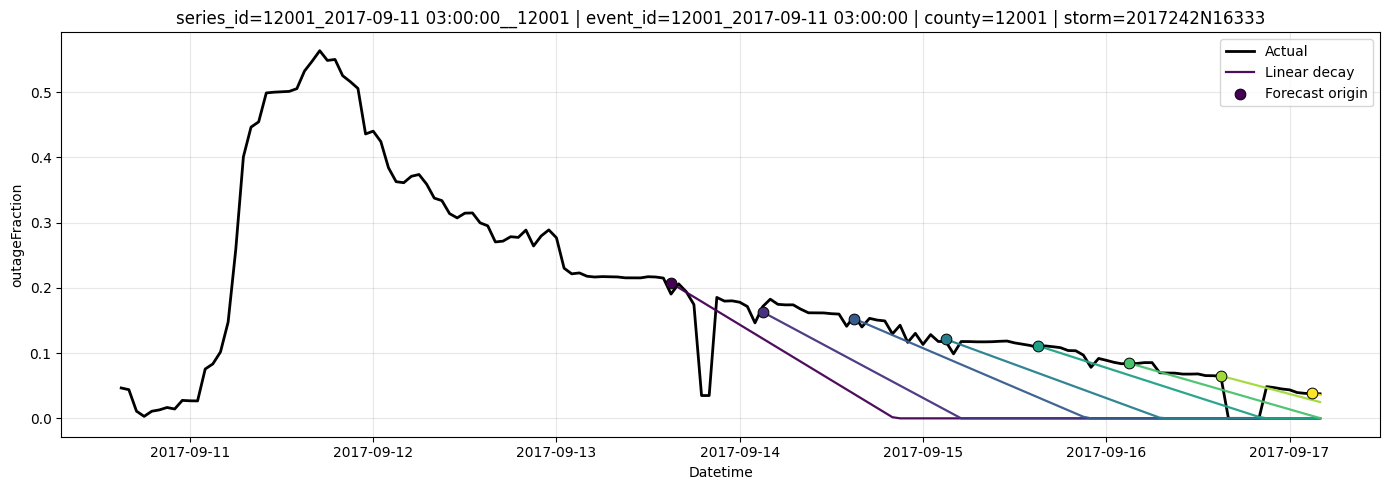

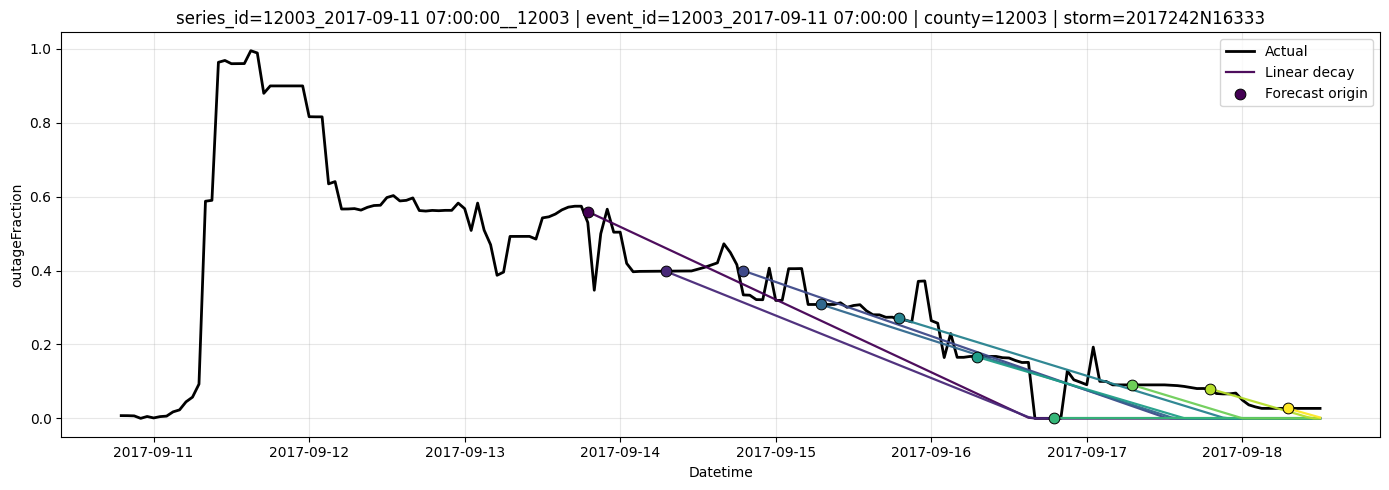

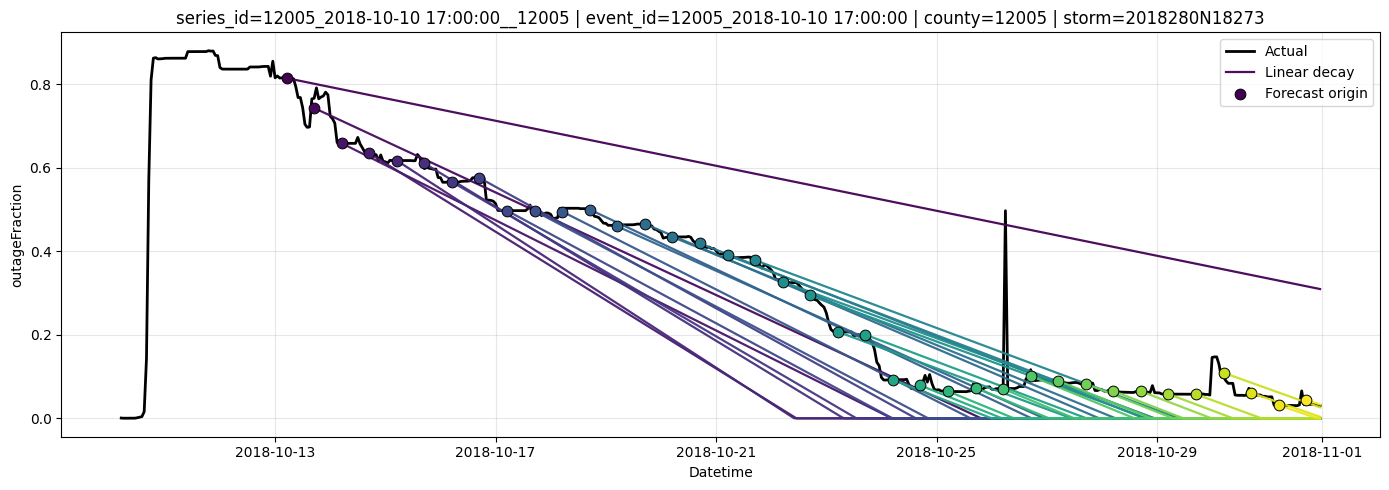

In [13]:
# ---------------------------------------------------------------------
# TFT-style plot: actual series plus linear forecasts from several origins
# ---------------------------------------------------------------------
def plot_linear_decay_paths(series_id: str, max_origins: int = 50) -> None: # define the max # of origins (i think we want as many as we can fit!)
    series_df = get_series(series_id)
    if series_df.empty:
        return

    times = series_df["datetime"].drop_duplicates().sort_values().to_list()
    start_time = times[0] + pd.Timedelta(hours=MIN_HISTORY_HOURS)
    origins = [t for t in times if t >= start_time][::ORIGIN_STEP_HOURS][:max_origins]

    if len(origins) == 0:
        return

    event_id = series_df["event_id"].iloc[0]
    county = series_df["CountyFIPS"].iloc[0]
    storm = series_df["storm"].iloc[0]

    cmap = plt.cm.viridis
    norm = Normalize(vmin=0, vmax=max(1, len(origins) - 1))

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(series_df["datetime"], series_df["outageFraction"], color="black", linewidth=2, label="Actual")

    for j, origin in enumerate(origins):
        fit = fit_peak_to_origin_slope(series_df, origin)
        if fit is None:
            continue

        color = cmap(norm(j))
        y0 = fit["y0"]
        slope = fit["slope"]

        path_df = forecast_path_to_window_end(series_df, origin, slope, y0)

        ax.plot(
            path_df["datetime"],
            path_df["y_pred"],
            color=color,
            linewidth=1.6,
            alpha=0.95,
            label="Linear decay" if j == 0 else None,
        )

        ax.scatter(
            origin,
            y0,
            color=color,
            s=60,
            marker="o",
            edgecolor="black",
            linewidth=0.7,
            zorder=10,
            label="Forecast origin" if j == 0 else None,
        )

    ax.set_title(f"series_id={series_id} | event_id={event_id} | county={county} | storm={storm}")
    ax.set_xlabel("Datetime")
    ax.set_ylabel("outageFraction")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


for sid in df["series_id"].drop_duplicates().head(3):
    plot_linear_decay_paths(sid)

Histogram of when the outage peaks:

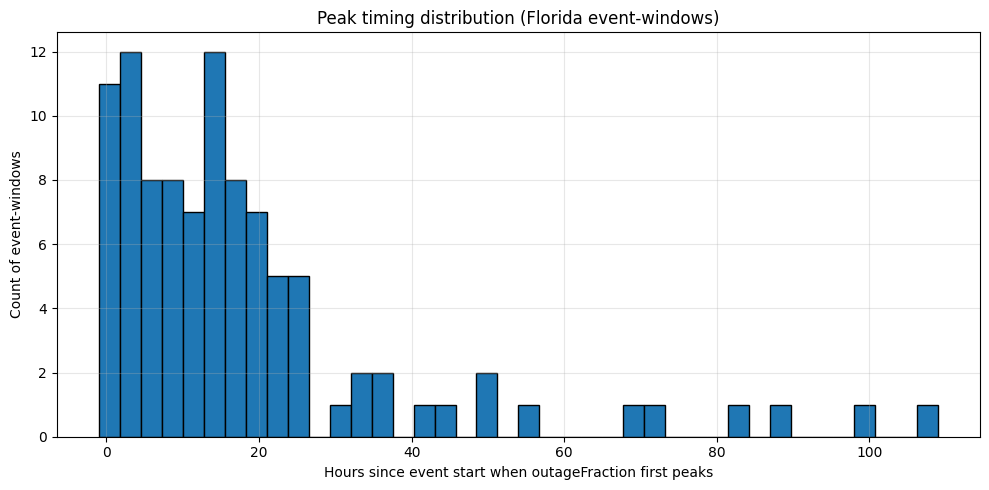

,event_id,CountyFIPS,event_start,peak_time,peak_outage,peak_hour_since_start
26,12001_2017-09-11 03:00:00,12001,2017-09-11 03:00:00,2017-09-11 17:00:00,0.563432,14.0
178,12003_2017-09-11 07:00:00,12003,2017-09-11 07:00:00,2017-09-11 15:00:00,0.994966,8.0
382,12005_2018-10-10 17:00:00,12005,2018-10-10 17:00:00,2018-10-11 19:00:00,0.880851,26.0
890,12007_2017-09-11 05:00:00,12007,2017-09-11 05:00:00,2017-09-11 17:00:00,0.969112,12.0
1076,12009_2022-09-29 07:00:00,12009,2022-09-29 07:00:00,2022-09-29 23:00:00,0.280680,16.0


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients"
model_df = pd.read_parquet(f"{path}\\florida_model_df.parquet")

df = model_df.copy()
df["datetime"] = pd.to_datetime(df["datetime"])
df["event_start"] = pd.to_datetime(df["event_start"])

# Optional quality filter
df = df.loc[df["customersTracked"] >= 0.30].copy()

# Make sure the grouping columns exist as ordinary columns
df = df.reset_index(drop=True)

# First row where outageFraction reaches its maximum within each event-county window
peak_idx = df.groupby(["event_id", "CountyFIPS"])["outageFraction"].idxmax()

peak_df = df.loc[peak_idx, ["event_id", "CountyFIPS", "event_start", "datetime", "outageFraction"]].copy()
peak_df = peak_df.rename(columns={
    "datetime": "peak_time",
    "outageFraction": "peak_outage",
})

peak_df["peak_hour_since_start"] = (
    (peak_df["peak_time"] - peak_df["event_start"]).dt.total_seconds() / 3600.0
)

plt.figure(figsize=(10, 5))
plt.hist(peak_df["peak_hour_since_start"], bins=40, edgecolor="black")
plt.xlabel("Hours since event start when outageFraction first peaks")
plt.ylabel("Count of event-windows")
plt.title("Peak timing distribution (Florida event-windows)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

peak_df.head()